<a href="https://colab.research.google.com/github/1021114Carlos/MIT_MM_Finance/blob/Finance-shop/Courses/Mathematical_Methods_Quantitative_Finance/M3_Time_Series_Data_and_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Library Packages

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
import yfinance as yf

Oder determination: AR(2) example

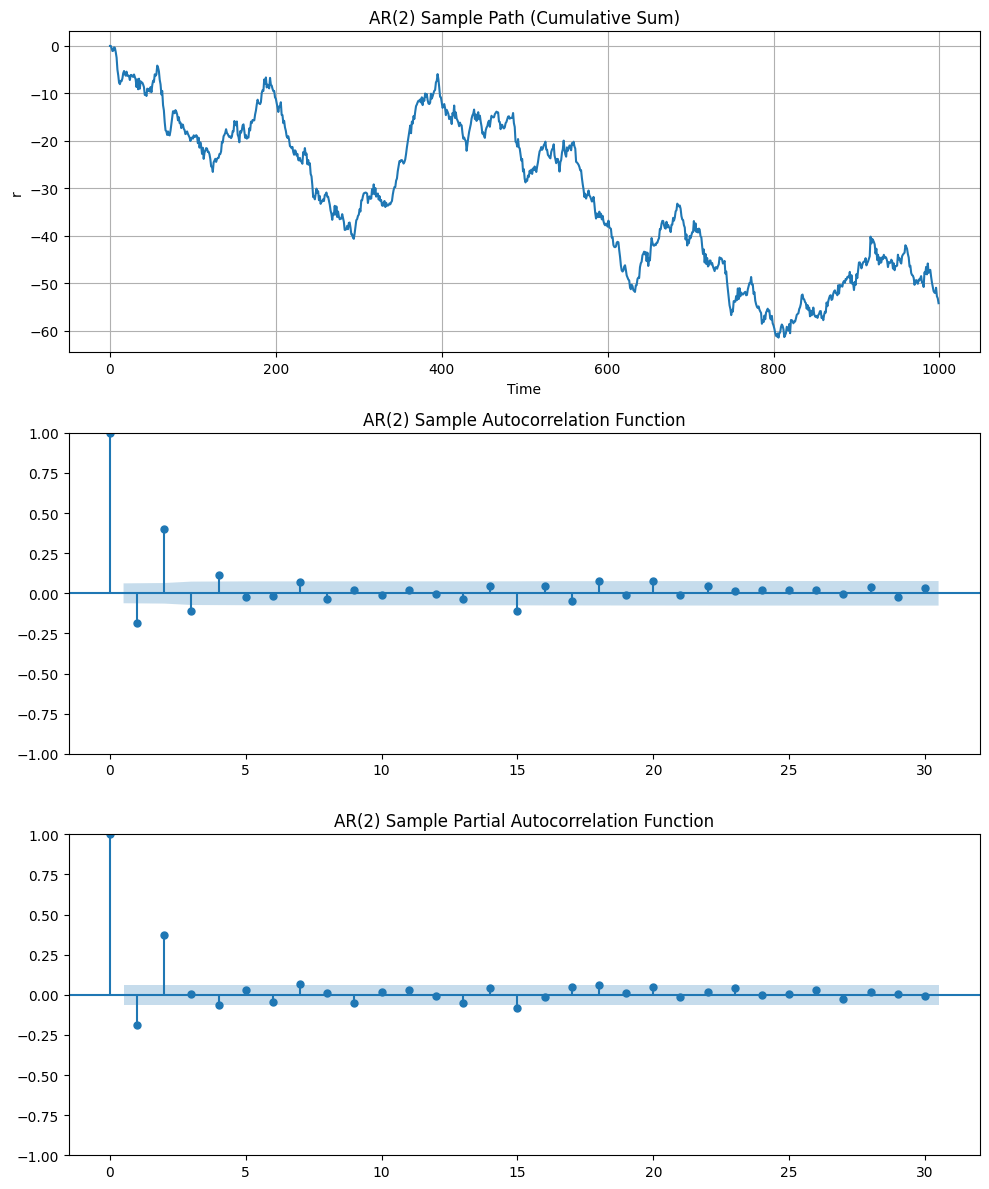

In [12]:
c0 = 0.001
c1 = -0.1
c2 = 0.4
sigma = 1
nt = 1000

r = np.zeros(nt)
z = np.random.normal(size=nt)  # generates random "white noise"

# Generates AR(2) process
for t in range(2, nt):
  r[t] = c0 + c1 * r[t-1] + c2 * r[t-2] + sigma * z[t]

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].plot(np.cumsum(r))
axes[0].set_title("AR(2) Sample Path (Cumulative Sum)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("r")
axes[0].grid(True)


# Plot autocorrelation function
plot_acf(r, ax=axes[1], title="AR(2) Sample Autocorrelation Function")
# Plot partial autocorrelation function
plot_pacf(r, ax=axes[2], title="AR(2) Sample Partial Autocorrelation Function")

plt.tight_layout()
plt.show()

Model Estimation AR(2)

In [15]:
df = pd.DataFrame(r)
df['y'] = df[0]
df['x1'] = df[0].shift(1)
df['x2'] = df[0].shift(2)
df = df.dropna()

# Linear regression (ols)
ar2model = sm.OLS(df['y'], sm.add_constant(df[['x1', 'x2']])).fit()
print(ar2model.summary())

# method 2: using the arima function
model200 = ARIMA(r, order=(2, 0, 0)).fit()
print(model200.summary())

model500 = ARIMA(r, order=(5,0,0)).fit()
print(model500.summary())



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     103.0
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           2.14e-41
Time:                        12:25:40   Log-Likelihood:                -1383.7
No. Observations:                 998   AIC:                             2773.
Df Residuals:                     995   BIC:                             2788.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0407      0.031     -1.321      0.1

Order determination MA(2)

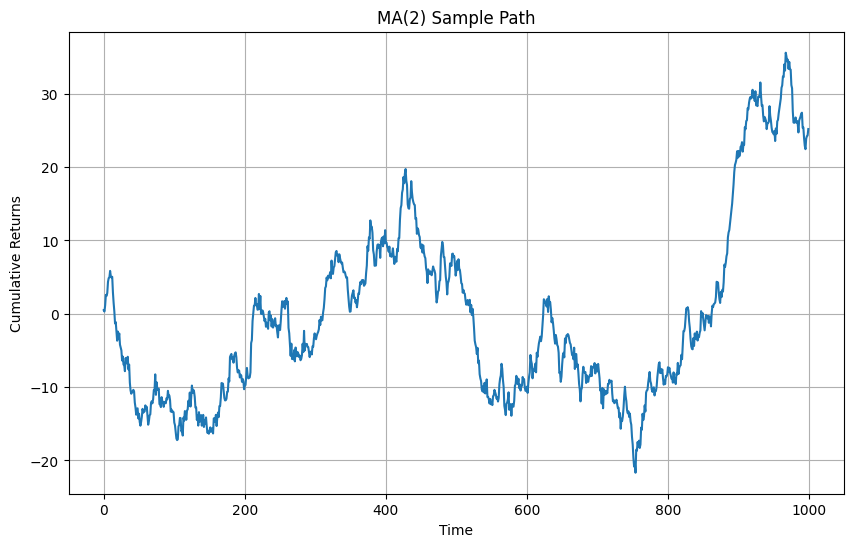

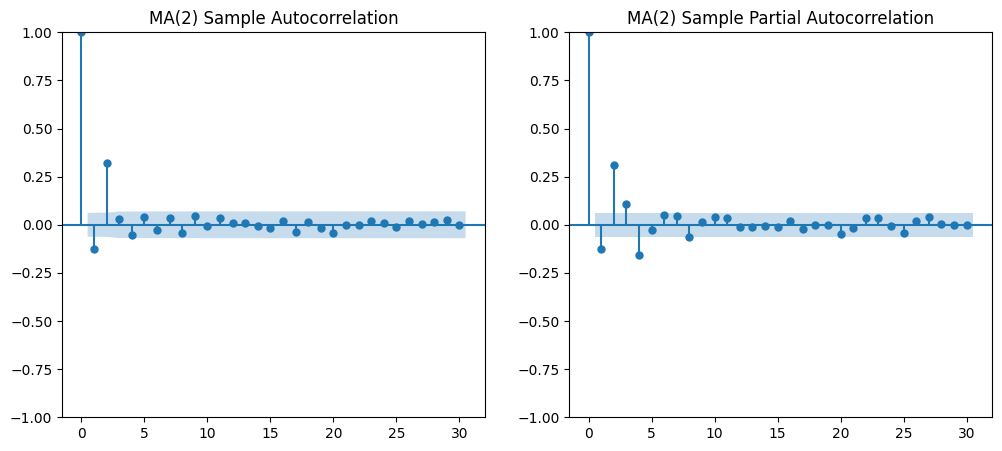

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1397.273
Date:                Thu, 02 Apr 2026   AIC                           2802.547
Time:                        13:19:20   BIC                           2822.178
Sample:                             0   HQIC                          2810.008
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0248      0.041      0.605      0.545      -0.056       0.105
ma.L1         -0.1035      0.030     -3.455      0.001      -0.162      -0.045
ma.L2          0.4243      0.030     14.099      0.0

In [34]:
# --- Parameters ---
np.random.seed(42)  # Setting seed for reproducibility
mu = 0.0
sigma = 1.0
phi_1 = -0.1
phi_2 = 0.4
Nt = 1000

# Generate random "shocks" (z) from a normal distribution
z = np.random.normal(0, sigma, Nt)
r = np.zeros(Nt)

# r[1] and r[2] in R are index 0 and 1 in Python
r[0] = mu + z[0]
r[1] = mu + z[1] + phi_1 * z[0]

# Generate returns recursively
for t in range(2, Nt):
    r[t] = mu + z[t] + phi_1 * z[t-1] + phi_2 * z[t-2]

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(r))
plt.title("MA(2) Sample Path")
plt.xlabel("Time")
plt.ylabel("Cumulative Returns")
plt.grid(True)
plt.show()

# --- ACF and PACF Plots ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(r, ax=ax[0], title="MA(2) Sample Autocorrelation")
plot_pacf(r, ax=ax[1], title="MA(2) Sample Partial Autocorrelation")
plt.show()

# --- ARIMA Model Fitting ---
model = ARIMA(r, order=(0, 0, 2))
results = model.fit()
print(results.summary())


In [39]:
# fetch the data
ticker = "TR"
df = yf.download(ticker, start='1987-12-31', end='2017-12-31')

# plot adjusted price
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Adj Close'])
plt.title("TR adjusted price 1988-2017")
plt.grid(True)
plt.show()

# Compute daily returns
df['r'] =np.log(df["adj close"]).diff()
df = df.dropna()

# Plot the returns
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['r'])
plt.title("TR Daily returns 1988-2017")
plt.grid(True)
plt.show()

noise = np.random.normal(0, df['r'].std(), len(df))
plt.figure(figsize=(10, 5))
plt.plot(df.index, noise)
plt.ylim(-0.18, 0.18)
plt.title("White noise process with TR volatility")
plt.grid(True)
plt.show()









/tmp/ipykernel_16534/3066695917.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='1987-12-31', end='2017-12-31')
[*********************100%***********************]  1 of 1 completed


KeyError: 'Adj Close'

<Figure size 1000x500 with 0 Axes>

/tmp/ipykernel_16534/230872459.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="1987-12-31", end="2017-12-31")
[*********************100%***********************]  1 of 1 completed


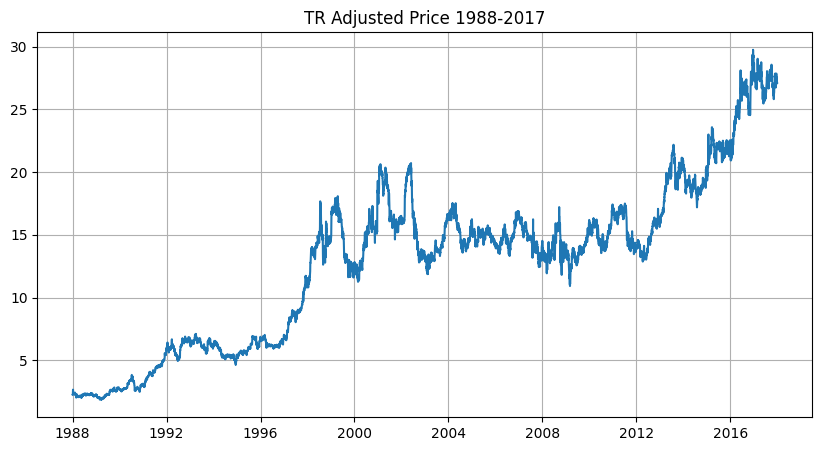

KeyError: 'Adj Close'

In [41]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Fetch the data
ticker = "TR"
df = yf.download(ticker, start="1987-12-31", end="2017-12-31")

# 2. Plot the Adjusted Price
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Close'])
plt.title("TR Adjusted Price 1988-2017")
plt.grid(True)
plt.show()

# 3. Compute Daily Returns (using log math)
df['r'] = np.log(df['Adj Close']).diff()
df = df.dropna() # Remove the first row since it has no "yesterday" to compare to

# 4. Plot the Returns
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['r'])
plt.title("TR Daily Returns 1988-2017")
plt.grid(True)
plt.show()

# 5. Compare to "White Noise" (Random scribbles)
noise = np.random.normal(0, df['r'].std(), len(df))
plt.figure(figsize=(10, 5))
plt.plot(df.index, noise)
plt.ylim(-0.18, 0.18)
plt.title("White Noise Process with TR Volatility")
plt.grid(True)
plt.show()
